In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import sys

In [2]:
# Load the raw npz file
raw_data = np.load('simulation_data.npz')
y_vals = raw_data['y_vals']
u_plot = raw_data['u_plot']

# Assuming y_vals contains [Cart 1 Pos, Cart 1 Vel, Cart 2 Pos, Cart 2 Vel]
columns = ['Input Force (u)', 'Cart 1 Pos (x1)', 'Cart 1 Vel (x1_dot)', 'Cart 2 Pos (x2)', 'Cart 2 Vel (x2_dot)']

# Create a DataFrame combining both raw arrays
# We use np.column_stack to attach the 1D u_plot alongside the 2D y_vals
df = pd.DataFrame(
    np.column_stack((u_plot, y_vals)),
    columns=columns
)

# Set the index name to represent Time Steps
df.index.name = 'Time Step'
display(df.head(10))


,Input Force (u),Cart 1 Pos (x1),Cart 1 Vel (x1_dot),Cart 2 Pos (x2),Cart 2 Vel (x2_dot)
Time Step,,,,,
0,0.993428,0.000000,0.000000,0.000000e+00,0.000000
1,0.993428,0.000197,0.039277,6.578013e-07,0.000197
2,0.993428,0.000783,0.077646,5.227087e-06,0.000781
3,0.993428,0.001747,0.115126,1.752287e-05,0.001740
4,0.993428,0.003082,0.151736,4.125689e-05,0.003066
5,0.993428,0.004779,0.187495,8.003968e-05,0.004749
6,0.993428,0.006829,0.222419,1.373827e-04,0.006777
7,0.993428,0.009225,0.256528,2.167003e-04,0.009142
8,0.993428,0.011957,0.289837,3.213117e-04,0.011834


In [3]:
# normalize the data 
y_mean, y_std = y_vals.mean(axis=0), y_vals.std(axis=0)
u_mean, u_std = u_plot.mean(), u_plot.std()

y_norm = (y_vals - y_mean) / (y_std + 1e-8)
u_norm = (u_plot - u_mean) / (u_std + 1e-8)

# convert to torch tensors
Y = torch.tensor(y_norm, dtype=torch.float32)
U = torch.tensor(u_norm, dtype=torch.float32).unsqueeze(1)

print(f"Data is normalized. Final shapes ready for model:")
print(f"Y Shape: {Y.shape} | U Shape: {U.shape}")

Data is normalized. Final shapes ready for model:
Y Shape: torch.Size([20000, 4]) | U Shape: torch.Size([20000, 1])


# Changed tanh to ReLU

In the initial test, the vanilla RNN using `tanh` activations and a high learning rate ($0.001$) failed to learn the dynamics. Instead, it suffered from vanishing gradients over the 1000-step sequences and collapsed into a local minimum. It essetially set $h_k = u_k$ (its hidden memory) and made $h_k \times W_{hh} + u_k \times W_{uh} + b_h = 0$ to create a direct, proportional mapping of the input force (resulting in boxy, square-wave predictions).

To force the network to learn continuous physics rather than step-functions, we must first stabilize the mathematical optimization:

1. **Activation Swap:** We replace `tanh` with `ReLU` inside the hidden state update. `ReLU` does not squash positive numbers, allowing the gradient (momentum) to survive much longer time horizons without vanishing.
2. **Hidden State Expansion:** We increase the hidden memory size to provide the network with enough dimensional space to simulate the integration of two independent moving masses.

Now the model doesnt simply just squash $h_k$ to -1 and 1 anymore after switching to relu. Instead, it now sets all $h_k$ to 0 if < 0 or else keeps it. 

In [4]:
# define the model
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        
        # Memory Update Weights
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
        self.W_uh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.1)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))
        
        # State Prediction Weights
        self.W_hx = nn.Parameter(torch.randn(hidden_size, output_size) * 0.1)
        self.b_x = nn.Parameter(torch.zeros(output_size))
    
    def forward(self, u_seq):
        # get sequence length
        seq_len = u_seq.shape[0]

        # initialize hidden state
        h_k = torch.zeros(self.hidden_size, device=u_seq.device)

        # initialize list to store predictions
        y_pred = []

        # loop through the sequence
        for k in range(seq_len):
            # get current input
            u_k = u_seq[k]

            # update hidden state
            h_k = torch.relu(h_k @ self.W_hh + u_k @ self.W_uh + self.b_h)

            # predict next state
            y_k = h_k @ self.W_hx + self.b_x

            # store prediction
            y_pred.append(y_k)

        # convert list to tensor
        y_pred = torch.stack(y_pred)

        return y_pred

# Training with `hidden_size=4` and `seq_len=100`. Also lowered learning rate to 0.0001 and applied gradient clipping

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# train the model
model = RNN(input_size=1, hidden_size=4, output_size=4).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# training loop
n_epochs = 1000
seq_len = 100

loss_history = []

batch_size = 16

for epoch in range(n_epochs):
    # zero the gradients
    optimizer.zero_grad()
    
    batch_loss = 0

    for _ in range(batch_size):
        # Pick a random starting point in the sequence
        start_idx = np.random.randint(0, len(U) - seq_len)
        end_idx = start_idx + seq_len
        
        # Get the chunks of data using slicing [start_idx:end_idx]
        U_chunk = U[start_idx:end_idx].to(device)
        Y_chunk = Y[start_idx:end_idx].to(device)
        
        # Forward pass
        Y_pred_chunk = model(U_chunk)
        
        # Calculate Loss
        loss = criterion(Y_pred_chunk, Y_chunk)
        loss = loss/batch_size
        
        # Backpropagate and Update
        loss.backward()

        batch_loss += (loss.item() * batch_size)
        
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    loss_history.append(loss.item())
    
    # Print the loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Average Batch Loss: {batch_loss / batch_size:.4f}")

Training on: cuda
Epoch 10/1000, Average Batch Loss: 0.5588
Epoch 20/1000, Average Batch Loss: 0.8293
Epoch 30/1000, Average Batch Loss: 1.2306
Epoch 40/1000, Average Batch Loss: 0.7147
Epoch 50/1000, Average Batch Loss: 1.4472
Epoch 60/1000, Average Batch Loss: 1.0842
Epoch 70/1000, Average Batch Loss: 0.7321
Epoch 80/1000, Average Batch Loss: 1.0187
Epoch 90/1000, Average Batch Loss: 0.9869
Epoch 100/1000, Average Batch Loss: 1.1758
Epoch 110/1000, Average Batch Loss: 0.8154
Epoch 120/1000, Average Batch Loss: 0.8986
Epoch 130/1000, Average Batch Loss: 0.8273
Epoch 140/1000, Average Batch Loss: 1.0175
Epoch 150/1000, Average Batch Loss: 0.9173
Epoch 160/1000, Average Batch Loss: 0.9159
Epoch 170/1000, Average Batch Loss: 0.9715
Epoch 180/1000, Average Batch Loss: 0.8399
Epoch 190/1000, Average Batch Loss: 0.8369
Epoch 200/1000, Average Batch Loss: 1.0517
Epoch 210/1000, Average Batch Loss: 1.0186
Epoch 220/1000, Average Batch Loss: 0.9326
Epoch 230/1000, Average Batch Loss: 0.7560
Ep

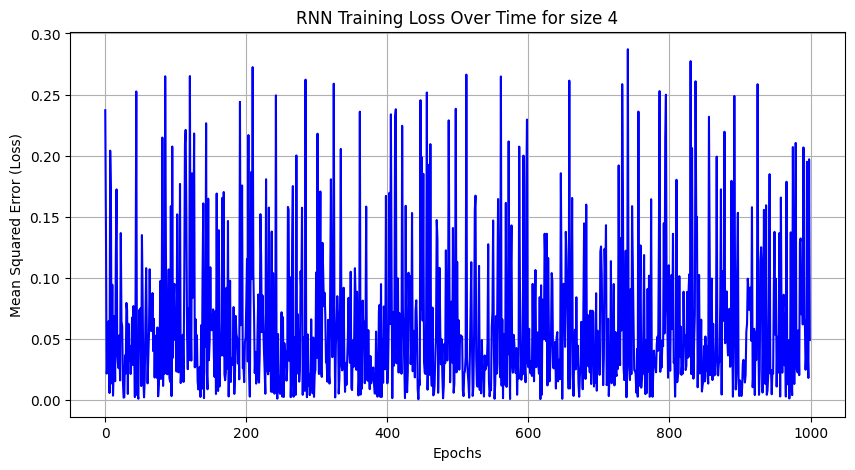

In [7]:
# Plot the Learning Curve
plt.figure(figsize=(10, 5))

# Plot the saved list
plt.plot(loss_history, color='blue')
plt.title('RNN Training Loss Over Time for size 4')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True)
plt.show()


While swapping to `ReLU` solves the vanishing gradient problem, it introduces a new instability: exploding gradients. Because `ReLU` is unbounded, multiplying values repeatedly over long time sequences causes the internal tensors to grow exponentially, resulting in chaotic loss spikes.

To stabilize the training loop, we implement two standard machine learning guardrails:
1. **Mini-Batch Averaging:** Instead of updating weights after evaluating a single random sequence, we evaluate a batch of 16 sequences, calculate the average error, and take a single, smooth step down the loss curve.
2. **Gradient Clipping:** Before the optimizer steps, we mathematically cap the maximum norm of the gradients (`max_norm=1.0`). This acts as a hard ceiling, preventing `ReLU` explosions from destabilizing the weight matrices.

Evaluating trained RNN for size 4 


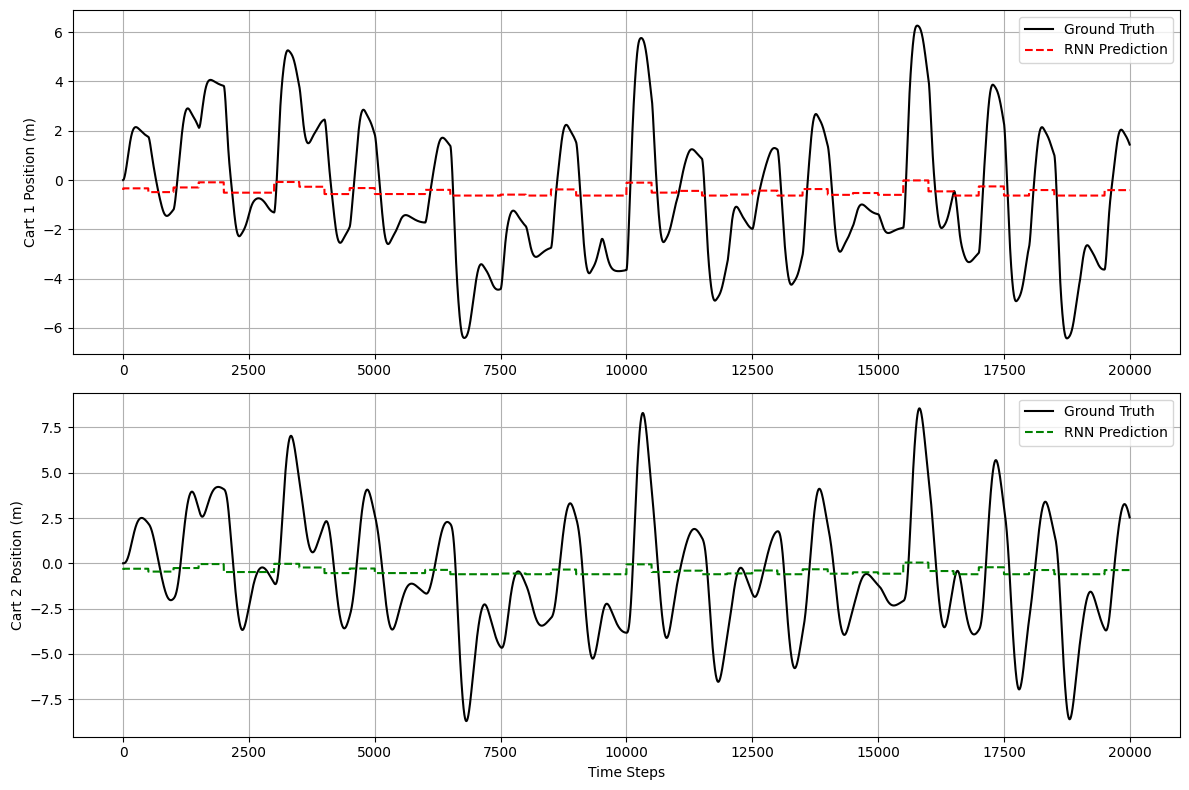

In [8]:
# train the model
print("Evaluating trained RNN for size 4 ")
with torch.no_grad():
    # Pass the ENTIRE sequence U through the model
    device = next(model.parameters()).to(device)
    Y_pred_norm = model(U.to(device))
    # Convert to numpy and un-normalize
    Y_pred = Y_pred_norm.cpu().numpy() * y_std + y_mean

# Plotting Results
plt.figure(figsize=(12, 8))

# Plot Cart 1 Position (x1)
plt.subplot(2, 1, 1)
plt.plot(y_vals[:, 0], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 0], 'r--', label='RNN Prediction')
plt.ylabel('Cart 1 Position (m)')
plt.legend()
plt.grid(True)

# Plot Cart 2 Position (x2)
plt.subplot(2, 1, 2)
plt.plot(y_vals[:, 2], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 2], 'g--', label='RNN Prediction')
plt.ylabel('Cart 2 Position (m)')
plt.xlabel('Time Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

As seen in the plot below, applying the mathematical guardrails successfully stopped the network from hallucinating the "lazy" square-wave physics. However, the resulting prediction is a flat line. 

This is an expected symptom of the **Dead ReLU** problem interacting with an open-loop architecture.
* The network is currently trying to learn the mapping $u_k \rightarrow x_{k+1}$. 
* From a control theory perspective, it is impossible to predict absolute position from force without knowing the initial conditions (the constant of integration).
* At the start of every sequence, the hidden state is zeroed out. When negative input forces are fed into the network, the `ReLU` functions output strict zeros. 

Because the network cannot "see" the true physical state of the carts, and the guardrails prevent it from cheating, the `ReLU` activations die out. The hidden memory matrix is wiped, and the network defaults to outputting its static bias vector (the flat line). 

To fix this, we must transition the architecture from a blind open-loop estimator to a closed-loop physics engine.

# Training with `hidden_size=64` and `seq_len=100`. Also lowered learning rate to 0.0001 and applied gradient clipping

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# train the model
model = RNN(input_size=1, hidden_size=64, output_size=4).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# training loop
n_epochs = 1000
seq_len = 100

loss_history = []

batch_size = 16

for epoch in range(n_epochs):
    # zero the gradients
    optimizer.zero_grad()
    
    batch_loss = 0

    for _ in range(batch_size):
        # Pick a random starting point in the sequence
        start_idx = np.random.randint(0, len(U) - seq_len)
        end_idx = start_idx + seq_len
        
        # Get the chunks of data using slicing [start_idx:end_idx]
        U_chunk = U[start_idx:end_idx].to(device)
        Y_chunk = Y[start_idx:end_idx].to(device)
        
        # Forward pass
        Y_pred_chunk = model(U_chunk)
        
        # Calculate Loss
        loss = criterion(Y_pred_chunk, Y_chunk)
        
        # Backpropagate and Update
        loss.backward()

        batch_loss += loss.item()
        
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    loss_history.append(loss.item())
    
    # Print the loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Average Batch Loss: {batch_loss / batch_size:.4f}")

Training on: cuda
Epoch 10/1000, Average Batch Loss: 0.8803
Epoch 20/1000, Average Batch Loss: 0.9171
Epoch 30/1000, Average Batch Loss: 1.3317
Epoch 40/1000, Average Batch Loss: 0.6334
Epoch 50/1000, Average Batch Loss: 0.5497
Epoch 60/1000, Average Batch Loss: 1.0614
Epoch 70/1000, Average Batch Loss: 1.2080
Epoch 80/1000, Average Batch Loss: 1.0644
Epoch 90/1000, Average Batch Loss: 0.7549
Epoch 100/1000, Average Batch Loss: 0.7362
Epoch 110/1000, Average Batch Loss: 0.6458
Epoch 120/1000, Average Batch Loss: 0.7781
Epoch 130/1000, Average Batch Loss: 0.6113
Epoch 140/1000, Average Batch Loss: 1.0650
Epoch 150/1000, Average Batch Loss: 0.6175
Epoch 160/1000, Average Batch Loss: 0.4471
Epoch 170/1000, Average Batch Loss: 0.5561
Epoch 180/1000, Average Batch Loss: 1.0598
Epoch 190/1000, Average Batch Loss: 0.7585
Epoch 200/1000, Average Batch Loss: 0.6186
Epoch 210/1000, Average Batch Loss: 0.6217
Epoch 220/1000, Average Batch Loss: 0.8589
Epoch 230/1000, Average Batch Loss: 0.5327
Ep

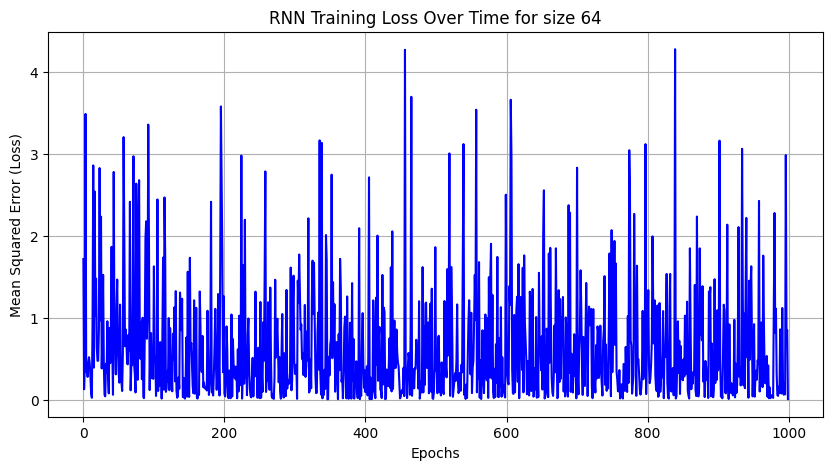

In [10]:
# Plot the Learning Curve
plt.figure(figsize=(10, 5))

# Plot the saved list
plt.plot(loss_history, color='blue')
plt.title('RNN Training Loss Over Time for size 64')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True)
plt.show()


Evaluating trained RNN for size 64


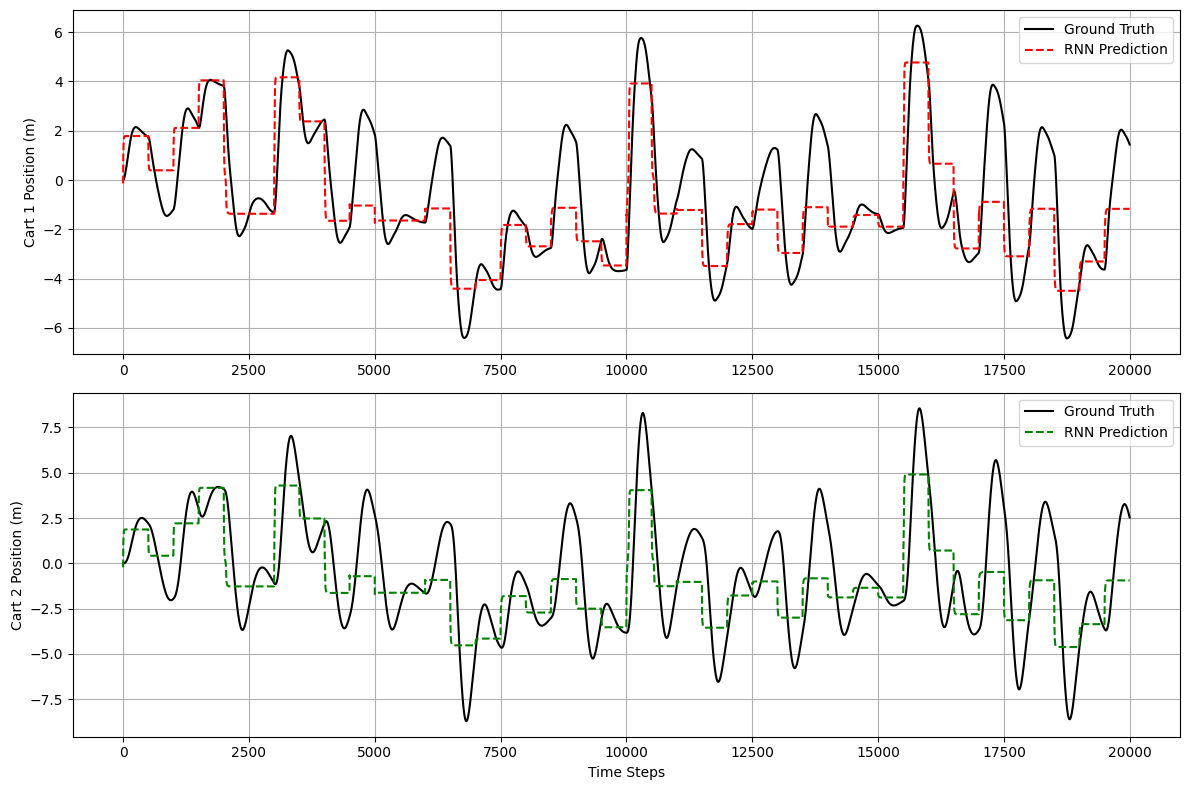

In [11]:
# train the model
print("Evaluating trained RNN for size 64")
with torch.no_grad():
    # Pass the ENTIRE sequence U through the model
    device = next(model.parameters()).to(device)
    Y_pred_norm = model(U.to(device))
    # Convert to numpy and un-normalize
    Y_pred = Y_pred_norm.cpu().numpy() * y_std + y_mean

# Plotting Results
plt.figure(figsize=(12, 8))

# Plot Cart 1 Position (x1)
plt.subplot(2, 1, 1)
plt.plot(y_vals[:, 0], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 0], 'r--', label='RNN Prediction')
plt.ylabel('Cart 1 Position (m)')
plt.legend()
plt.grid(True)

# Plot Cart 2 Position (x2)
plt.subplot(2, 1, 2)
plt.plot(y_vals[:, 2], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 2], 'g--', label='RNN Prediction')
plt.ylabel('Cart 2 Position (m)')
plt.xlabel('Time Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()